Using device: cuda
Loading CIFAR-100 dataset...
Chosen classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Train shape: (10000, 32, 32, 3), Test shape: (2000, 32, 32, 3)
Training samples: 10000, Test samples: 2000

=== Training CNN ===
[CNN][Epoch 1/15] Loss=2.4841 Acc=23.99% | ValLoss=2.0671 ValAcc=37.45%
[CNN][Epoch 2/15] Loss=2.0090 Acc=38.58% | ValLoss=1.7883 ValAcc=45.90%
[CNN][Epoch 4/15] Loss=1.5410 Acc=52.42% | ValLoss=1.5105 ValAcc=54.10%
[CNN][Epoch 6/15] Loss=1.2232 Acc=61.38% | ValLoss=1.3755 ValAcc=58.10%
[CNN][Epoch 8/15] Loss=0.9719 Acc=69.08% | ValLoss=1.3403 ValAcc=59.35%
[CNN][Epoch 10/15] Loss=0.7974 Acc=74.74% | ValLoss=1.3236 ValAcc=60.85%
[CNN][Epoch 12/15] Loss=0.6668 Acc=78.75% | ValLoss=1.3346 ValAcc=61.35%
[CNN][Epoch 14/15] Loss=0.6083 Acc=80.65% | ValLoss=1.3320 ValAcc=61.45%
CNN Parameters: 546,388

=== Training FCFNN ===
[FCFNN][Epoch 1/15] Loss=2.5484 Acc=22.12% | ValLoss=2.2526 ValAcc=30.35%
[FCFNN][Epoch 2/15] Loss=2.2702 Acc

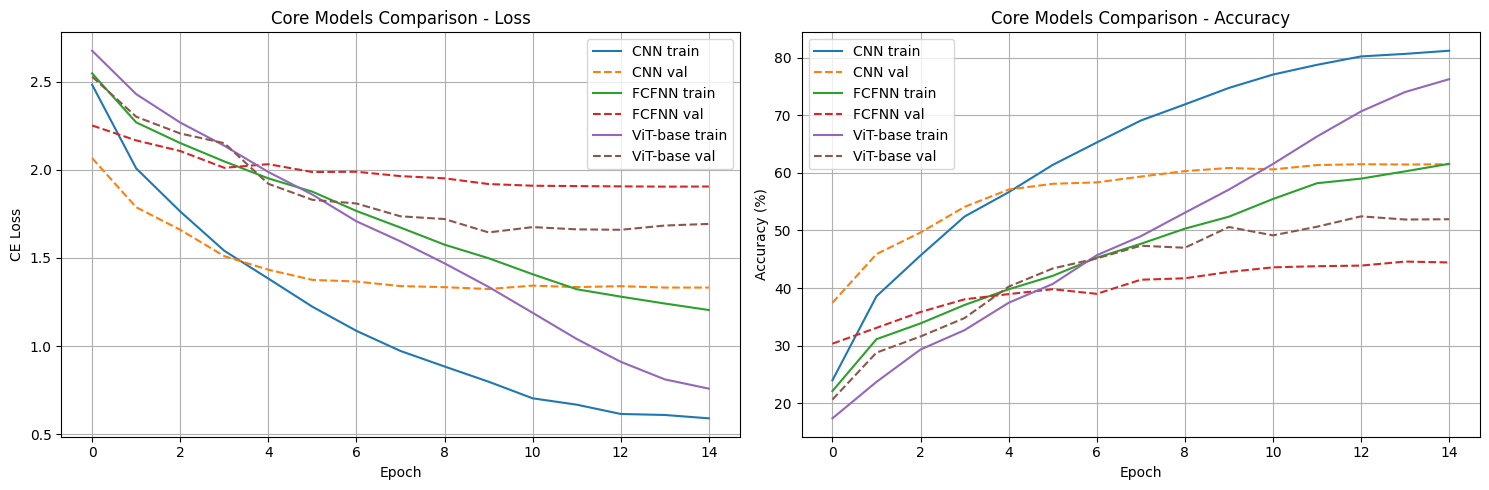

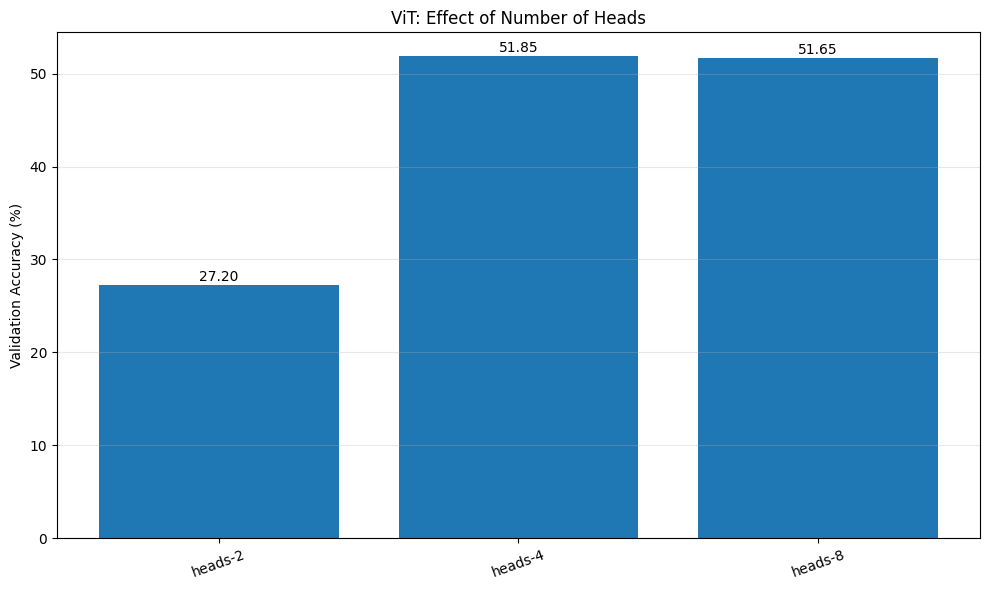

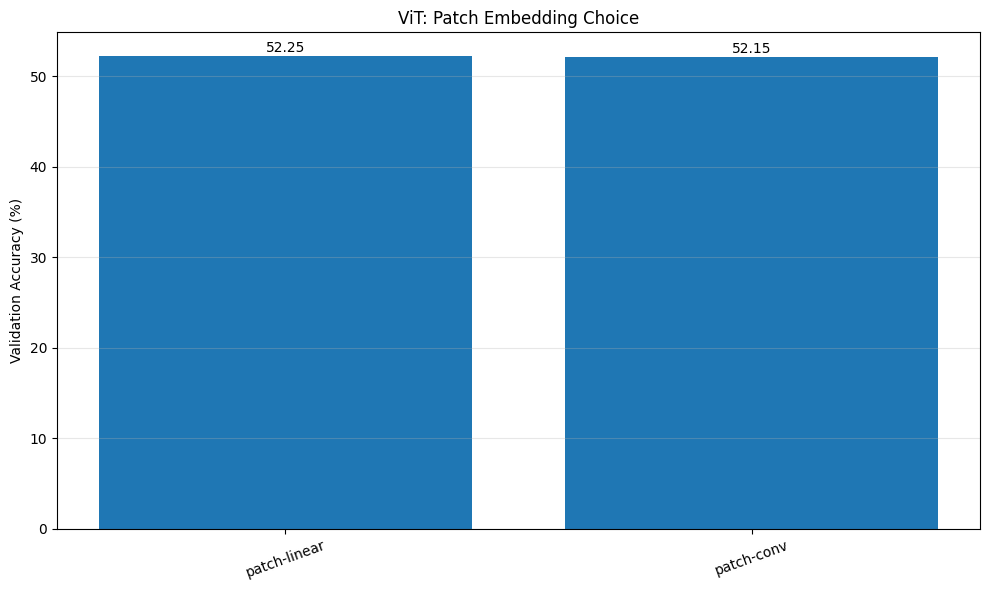

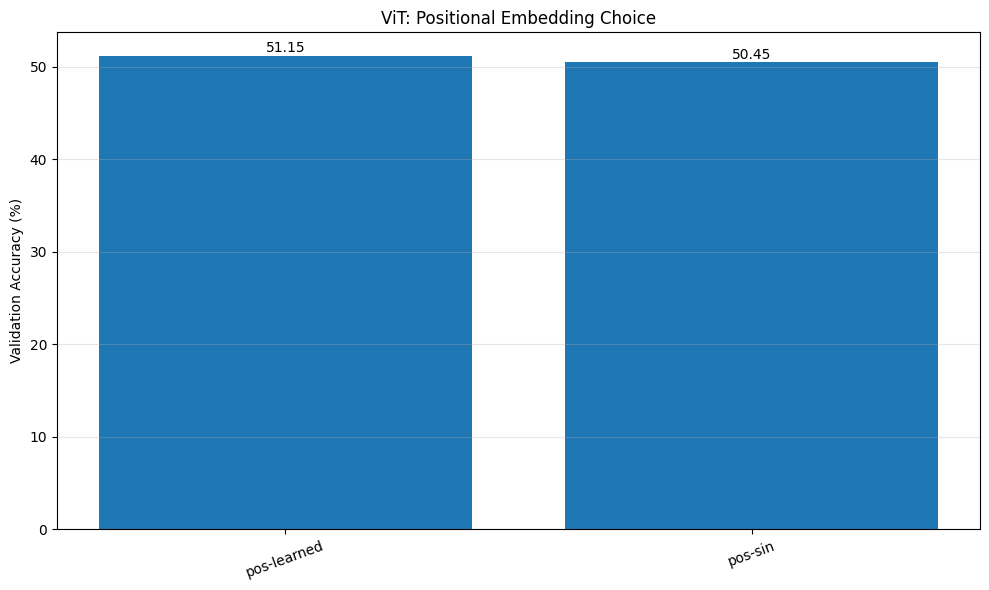


FINAL VALIDATION ACCURACY SUMMARY
CNN                 :  61.50%
FCFNN               :  44.45%
ViT-base            :  51.95%
heads-2             :  27.20%
heads-4             :  51.85%
heads-8             :  51.65%
patch-linear        :  52.25%
patch-conv          :  52.15%
pos-learned         :  51.15%
pos-sin             :  50.45%


In [20]:
# assignment14_vit_comparison.py
# ---------------------------------------------------
# PyTorch code for Assignment 14:
# - ViT vs CNN vs FCFNN on 20 ImageNet classes
# - Effect of ViT heads, patch embedding, positional embedding
# ---------------------------------------------------
import os
import random
import math
import argparse
from pathlib import Path
from collections import defaultdict
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Check if tensorflow is available, otherwise use a fallback
try:
    from tensorflow.keras.datasets import cifar100
    TF_AVAILABLE = True
except ImportError:
    print("TensorFlow not available, using PyTorch CIFAR-100 instead")
    TF_AVAILABLE = False

# ----------------------------
# Utilities
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ---------- Load CIFAR-100 instead of ImageNet ----------
def load_imagenet_subset(num_classes=20):
    if TF_AVAILABLE:
        (x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode="fine")
    else:
        # Fallback to PyTorch CIFAR-100
        from torchvision.datasets import CIFAR100
        transform_basic = transforms.Compose([transforms.ToTensor()])
        
        train_dataset = CIFAR100(root='./data', train=True, download=True, transform=transform_basic)
        test_dataset = CIFAR100(root='./data', train=False, download=True, transform=transform_basic)
        
        # Convert to numpy arrays
        x_train = np.array([np.array(img) for img, _ in train_dataset])
        y_train = np.array([label for _, label in train_dataset]).reshape(-1, 1)
        x_test = np.array([np.array(img) for img, _ in test_dataset])
        y_test = np.array([label for _, label in test_dataset]).reshape(-1, 1)

    # Select first N classes
    chosen_classes = list(range(num_classes))
    mask_train = np.isin(y_train, chosen_classes).flatten()
    mask_test  = np.isin(y_test, chosen_classes).flatten()

    x_train, y_train = x_train[mask_train], y_train[mask_train]
    x_test, y_test   = x_test[mask_test], y_test[mask_test]

    return (x_train, y_train), (x_test, y_test), chosen_classes

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ----------------------------
# Models
# ----------------------------
class PatchEmbedLinear(nn.Module):
    """Linear projection of flattened non-overlapping patches."""
    def __init__(self, img_size=32, patch_size=4, in_ch=3, embed_dim=384):
        super().__init__()
        assert img_size % patch_size == 0
        self.grid = img_size // patch_size
        self.patch_dim = in_ch * patch_size * patch_size
        self.proj = nn.Linear(self.patch_dim, embed_dim)

        self.patch_size = patch_size
        self.img_size = img_size
        self.in_ch = in_ch

    def forward(self, x):
        # x: [B, C, H, W]
        B, C, H, W = x.shape
        ps = self.patch_size
        # Unfold into patches: [B, C*ps*ps, N]
        patches = F.unfold(x, kernel_size=ps, stride=ps)  # [B, C*ps*ps, N]
        patches = patches.transpose(1, 2)                 # [B, N, C*ps*ps]
        return self.proj(patches)                         # [B, N, D]

class PatchEmbedConv(nn.Module):
    """Conv2d with kernel=stride=patch_size to get patch embeddings (efficient)."""
    def __init__(self, img_size=32, patch_size=4, in_ch=3, embed_dim=384):
        super().__init__()
        assert img_size % patch_size == 0
        self.proj = nn.Conv2d(in_ch, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.grid = img_size // patch_size

    def forward(self, x):
        x = self.proj(x)                # [B, D, H/ps, W/ps]
        x = x.flatten(2).transpose(1, 2)  # [B, N, D]
        return x

def sinusoidal_pos_embed(n_positions, dim, device):
    # Classic transformer sinusoidal embeddings
    position = torch.arange(n_positions, device=device).unsqueeze(1)  # [N,1]
    div_term = torch.exp(torch.arange(0, dim, 2, device=device) * (-math.log(10000.0) / dim))
    pe = torch.zeros(n_positions, dim, device=device)
    pe[:, 0::2] = torch.sin(position * div_term)
    if dim % 2 == 1:
        pe[:, 1::2] = torch.cos(position * div_term[:-1])
    else:
        pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # [N, D]

class ViTEncoderBlock(nn.Module):
    def __init__(self, embed_dim=384, num_heads=6, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden = int(embed_dim * mlp_ratio)
        self.mlp  = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # x: [B, N+1, D]
        h = self.norm1(x)
        attn_out, _ = self.attn(h, h, h, need_weights=False)  # self-attn
        x = x + attn_out
        h = self.norm2(x)
        x = x + self.mlp(h)
        return x

class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_ch=3,
        num_classes=20,
        embed_dim=384,
        depth=6,
        num_heads=6,
        mlp_ratio=4.0,
        dropout=0.0,
        patch_embed_type='conv',      # 'conv' or 'linear'
        pos_embed_type='learned',     # 'learned' or 'sin'
    ):
        super().__init__()
        if patch_embed_type == 'conv':
            self.patch_embed = PatchEmbedConv(img_size, patch_size, in_ch, embed_dim)
        else:
            self.patch_embed = PatchEmbedLinear(img_size, patch_size, in_ch, embed_dim)

        num_patches = (img_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed_type = pos_embed_type
        if pos_embed_type == 'learned':
            self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
            nn.init.trunc_normal_(self.pos_embed, std=0.02)

        self.blocks = nn.ModuleList([
            ViTEncoderBlock(embed_dim, num_heads, mlp_ratio, dropout) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)

        self.img_size = img_size
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.num_patches = num_patches

    def forward(self, x):
        # x: [B,C,H,W]
        B = x.size(0)
        x = self.patch_embed(x)  # [B, N, D]
        cls = self.cls_token.expand(B, -1, -1)  # [B,1,D]
        x = torch.cat([cls, x], dim=1)          # [B, N+1, D]

        if self.pos_embed_type == 'learned':
            x = x + self.pos_embed
        else:
            # sinusoidal (CLS gets its own position)
            pe = sinusoidal_pos_embed(self.num_patches + 1, self.embed_dim, x.device)  # [N+1, D]
            x = x + pe.unsqueeze(0)

        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        cls_out = x[:, 0]              # [B, D]
        logits = self.head(cls_out)    # [B, num_classes]
        return logits

# ------------------ Small CNN ------------------
class SmallCNN(nn.Module):
    def __init__(self, num_classes=20):
        super(SmallCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

# ------------------ Feed-Forward NN ------------------
class FCFNN(nn.Module):
    def __init__(self, num_classes=20, img_size=32):
        super(FCFNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3 * img_size * img_size, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        return self.fc3(x)

# ----------------------------
# Train / Eval Functions
# ----------------------------
def accuracy(output, target, topk=(1,)):
    with torch.no_grad():
        maxk = max(topk)
        batch_size = target.size(0)
        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        res = []
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
            res.append((correct_k.mul_(100.0 / batch_size)).item())
        return res

def train_model(model, train_loader, test_loader, model_name="Model", epochs=10, lr=0.001):
    """Generic training function for all models"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, pred = outputs.max(1)
            correct += pred.eq(y).sum().item()
            total += y.size(0)
        
        train_acc = 100 * correct / total
        scheduler.step()

        # ---- Validation ----
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                loss = criterion(outputs, y)
                val_loss += loss.item()
                _, pred = outputs.max(1)
                val_correct += pred.eq(y).sum().item()
                val_total += y.size(0)
        val_acc = 100 * val_correct / val_total

        # Save history
        history['train_loss'].append(running_loss/len(train_loader))
        history['val_loss'].append(val_loss/len(test_loader))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"[{model_name}][Epoch {epoch+1}/{epochs}] "
                  f"Loss={running_loss/len(train_loader):.4f} Acc={train_acc:.2f}% | "
                  f"ValLoss={val_loss/len(test_loader):.4f} ValAcc={val_acc:.2f}%")

    return history, model

def train_cnn(train_loader, test_loader, num_classes=20, epochs=10, lr=0.001):
    model = SmallCNN(num_classes=num_classes).to(device)
    return train_model(model, train_loader, test_loader, "CNN", epochs, lr)

def train_fcfnn(train_loader, test_loader, num_classes=20, img_size=32, epochs=10, lr=0.001):
    model = FCFNN(num_classes=num_classes, img_size=img_size).to(device)
    return train_model(model, train_loader, test_loader, "FCFNN", epochs, lr)

def train_vit(name, patch_size=4, embed_dim=384, depth=6, num_heads=6,
              patch_embed_type='conv', pos_embed_type='learned',
              train_loader=None, test_loader=None, epochs=10, lr=0.001):
    """Train Vision Transformer with specified parameters"""
    model = VisionTransformer(
        img_size=32,
        patch_size=patch_size,
        in_ch=3,
        num_classes=20,
        embed_dim=embed_dim,
        depth=depth,
        num_heads=num_heads,
        mlp_ratio=4.0,
        dropout=0.1,
        patch_embed_type=patch_embed_type,
        pos_embed_type=pos_embed_type,
    ).to(device)
    
    return train_model(model, train_loader, test_loader, f"ViT-{name}", epochs, lr)

def plot_curves(histories, title="Training Curves"):
    """Plot training curves for multiple models"""
    plt.figure(figsize=(15, 5))
    
    # Loss
    plt.subplot(1, 2, 1)
    for name, h in histories.items():
        plt.plot(h['train_loss'], label=f"{name} train")
        plt.plot(h['val_loss'], linestyle='--', label=f"{name} val")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("CE Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1, 2, 2)
    for name, h in histories.items():
        plt.plot(h['train_acc'], label=f"{name} train")
        plt.plot(h['val_acc'], linestyle='--', label=f"{name} val")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def bar_plot(metric_dict, title, ylabel):
    """Create bar plot for comparing metrics"""
    names = list(metric_dict.keys())
    vals = [metric_dict[k] for k in names]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(names, vals)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=20)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars, vals):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# ----------------------------
# Main Experiment
# ----------------------------
def main():
    seed_everything(42)
    
    print("Loading CIFAR-100 dataset...")
    # ------------------------------
    # Load CIFAR-100 (20 classes only)
    # ------------------------------
    (x_train, y_train), (x_test, y_test), chosen = load_imagenet_subset(num_classes=20)
    print(f"Chosen classes: {chosen}")
    print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")

    # Convert to torch tensors
    x_train = torch.tensor(x_train).permute(0, 3, 1, 2).float() / 255.0
    x_test = torch.tensor(x_test).permute(0, 3, 1, 2).float() / 255.0
    y_train = torch.tensor(y_train).long().squeeze()
    y_test = torch.tensor(y_test).long().squeeze()

    # Normalize using CIFAR stats (closer to our data than ImageNet)
    normalize = transforms.Normalize(mean=(0.5071, 0.4867, 0.4408),
                                   std=(0.2675, 0.2565, 0.2761))
    x_train = normalize(x_train)
    x_test = normalize(x_test)

    # Wrap in dataset & dataloader
    train_ds = TensorDataset(x_train, y_train)
    test_ds = TensorDataset(x_test, y_test)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2)

    print(f"Training samples: {len(train_ds)}, Test samples: {len(test_ds)}")

    histories = {}
    epochs = 15  # Increased for better convergence
    
    # ------------------------------
    # Train Small CNN
    # ------------------------------
    print("\n=== Training CNN ===")
    cnn_hist, cnn_model = train_cnn(train_loader, test_loader, epochs=epochs, lr=0.001)
    histories['CNN'] = cnn_hist
    cnn_val_acc = cnn_hist['val_acc'][-1]
    print(f"CNN Parameters: {count_params(cnn_model):,}")

    # ------------------------------
    # Train Feed-Forward NN (FCFNN)
    # ------------------------------
    print("\n=== Training FCFNN ===")
    fcf_hist, fcf_model = train_fcfnn(train_loader, test_loader, epochs=epochs, lr=0.001)
    histories['FCFNN'] = fcf_hist
    fcf_val_acc = fcf_hist['val_acc'][-1]
    print(f"FCFNN Parameters: {count_params(fcf_model):,}")

    # ------------------------------
    # Train Vision Transformer (baseline)
    # ------------------------------
    print("\n=== Training ViT-base ===")
    vit_hist, vit_model = train_vit("base",
        patch_size=4, embed_dim=256, depth=6, num_heads=8,
        patch_embed_type='conv', pos_embed_type='learned',
        train_loader=train_loader, test_loader=test_loader, epochs=epochs, lr=0.001)
    histories['ViT-base'] = vit_hist
    vit_base_acc = vit_hist['val_acc'][-1]
    print(f"ViT-base Parameters: {count_params(vit_model):,}")

    # ------------------------------
    # Effect of number of heads
    # ------------------------------
    print("\n=== Testing Effect of Number of Heads ===")
    head_settings = [2, 4, 8]
    head_results = {}
    for hnum in head_settings:
        print(f"\nTraining ViT with {hnum} heads...")
        h_hist, h_model = train_vit(f"heads{hnum}",
            patch_size=4, embed_dim=256, depth=6, num_heads=hnum,
            patch_embed_type='conv', pos_embed_type='learned',
            train_loader=train_loader, test_loader=test_loader, epochs=epochs, lr=0.001)
        histories[f"ViT-h{hnum}"] = h_hist
        head_results[f"heads-{hnum}"] = h_hist['val_acc'][-1]

    # ------------------------------
    # Effect of patch embedding
    # ------------------------------
    print("\n=== Testing Effect of Patch Embedding ===")
    pe_results = {}
    for pe_type in ['linear', 'conv']:
        print(f"\nTraining ViT with {pe_type} patch embedding...")
        p_hist, p_model = train_vit(f"patch-{pe_type}",
            patch_size=4, embed_dim=256, depth=6, num_heads=8,
            patch_embed_type=pe_type, pos_embed_type='learned',
            train_loader=train_loader, test_loader=test_loader, epochs=epochs, lr=0.001)
        histories[f"ViT-patch-{pe_type}"] = p_hist
        pe_results[f"patch-{pe_type}"] = p_hist['val_acc'][-1]

    # ------------------------------
    # Effect of positional embedding
    # ------------------------------
    print("\n=== Testing Effect of Positional Embedding ===")
    pos_results = {}
    for pos in ['learned', 'sin']:
        print(f"\nTraining ViT with {pos} positional embedding...")
        pos_hist, pos_model = train_vit(f"pos-{pos}",
            patch_size=4, embed_dim=256, depth=6, num_heads=8,
            patch_embed_type='conv', pos_embed_type=pos,
            train_loader=train_loader, test_loader=test_loader, epochs=epochs, lr=0.001)
        histories[f"ViT-pos-{pos}"] = pos_hist
        pos_results[f"pos-{pos}"] = pos_hist['val_acc'][-1]

    # ------------------------------
    # Plots
    # ------------------------------
    print("\n=== Creating Plots ===")
    
    # 1) Core comparison curves: CNN vs FCFNN vs ViT-base
    core_hist = {k: v for k, v in histories.items() if k in ['CNN', 'FCFNN', 'ViT-base']}
    plot_curves(core_hist, title="Core Models Comparison")

    # 2) Heads ablation bar plot
    bar_plot(head_results, "ViT: Effect of Number of Heads", "Validation Accuracy (%)")

    # 3) Patch embedding choice bar plot
    bar_plot(pe_results, "ViT: Patch Embedding Choice", "Validation Accuracy (%)")

    # 4) Positional embedding bar plot
    bar_plot(pos_results, "ViT: Positional Embedding Choice", "Validation Accuracy (%)")

    # ------------------------------
    # Final Summary
    # ------------------------------
    summary = {
        "CNN": cnn_val_acc,
        "FCFNN": fcf_val_acc,
        "ViT-base": vit_base_acc,
        **head_results,
        **pe_results,
        **pos_results,
    }
    
    print("\n" + "="*50)
    print("FINAL VALIDATION ACCURACY SUMMARY")
    print("="*50)
    for k, v in summary.items():
        print(f"{k:20s}: {v:6.2f}%")
    print("="*50)

if __name__ == "__main__":
    main()